
# Dimuon Resonance Analysis: Reconstructing the J/ψ and Υ Mesons from CMS Open Data

**Dataset:** 40,000 dimuon events (CMS 2011 Open Data, DoubleMu primary dataset) &nbsp;|&nbsp; **Particles:** J/ψ (charmonium) and Υ (bottomonium)

---

### Abstract

Two-muon ("dimuon") events recorded by the CMS detector at the LHC in 2011 are analyzed to reconstruct
the invariant mass spectrum of the parent resonance decaying to $\mu^+\mu^-$. Using only the measured
four-momenta of the two muons, we recover the $J/\psi$ (charmonium, $c\bar{c}$) and $\Upsilon$
(bottomonium, $b\bar{b}$) resonance peaks at their known PDG masses, characterize the event kinematics,
identify anomalous outlier events with an isolation-forest model, train and compare several classifiers
to discriminate the two species from kinematic features alone, build a regression model to predict one
muon's transverse momentum from the other muon's kinematics, and provide an interactive Plotly dashboard
for exploring the mass spectrum. This notebook is organized as a self-contained research workflow:
data → feature engineering → physics reconstruction → visualization → anomaly detection →
machine learning → interactive exploration → conclusions.

**Contents**

1. [Setup & Style Configuration](#1.-Setup-&-Style-Configuration)
2. [Data Loading & Exploratory Data Analysis](#2.-Data-Loading-&-Exploratory-Data-Analysis)
3. [Feature Engineering](#3.-Feature-Engineering)
4. [Physics Reconstruction — Rediscovering the Resonances](#4.-Physics-Reconstruction)
5. [Visualization & Storytelling](#5.-Visualization-&-Storytelling)
6. [Anomaly / Outlier Detection](#6.-Anomaly-Detection)
7. [Classification — J/ψ vs. Υ from Kinematics](#7.-Classification)
8. [Regression — Predicting Muon Kinematics](#8.-Regression)
9. [Interactive Dashboard](#9.-Interactive-Dashboard)
10. [Conclusions](#10.-Conclusions)



## 1. Setup & Style Configuration

We configure a consistent, publication-style plotting theme (serif fonts, minimal spines,
a colorblind-safe categorical palette, and high output resolution) used throughout the notebook,
so all figures share the same visual language.


In [4]:

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ---- Publication-style figure theme -----------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Georgia", "Times New Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# Okabe–Ito colorblind-safe palette
C_BLUE    = "#0072B2"   # J/psi
C_ORANGE  = "#D55E00"   # Upsilon
C_GREEN   = "#009E73"   # tertiary / normal
C_RED     = "#B3202E"   # anomaly / highlight
C_PURPLE  = "#CC79A7"
C_GREY    = "#666666"
CLASS_COLORS = {"J/psi": C_BLUE, "upsilon": C_ORANGE}

def panel_label(ax, label, x=-0.14, y=1.06):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom")

import os
os.makedirs("figs_nb", exist_ok=True)
print("Environment configured.")


Environment configured.



## 2. Data Loading & Exploratory Data Analysis

**Source:** [CMS Open Data — J/ψ→μμ (record 5203)](http://opendata.cern.ch/record/5203) and
[Υ→μμ (record 5206)](http://opendata.cern.ch/record/5206), released under CC0.

Each row is one *event* containing two reconstructed muon candidates (labelled `1` and `2`) with their
energy–momentum four-vector $(E, p_x, p_y, p_z)$, transverse momentum $p_T$, pseudorapidity $\eta$,
azimuthal angle $\phi$, electric charge $Q$, and reconstruction `type` (**G** = global muon,
**T** = tracker muon). The target `class` records which resonance (`J/psi` or `upsilon`) the event
was selected to represent.


In [5]:

df = pd.read_csv("psion_upsilon.csv", index_col=0)
print(f"Loaded {len(df):,} events, {df.shape[1]} columns")
df.head()


Loaded 40,000 events, 21 columns


,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,...,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,class
0,167807,1101779335,G,5.8830,3.6101,2.3476,4.0069,4.3062,0.8314,0.5766,...,G,5.5776,-3.4452,-3.3512,-2.8283,4.8062,-0.5589,-2.3700,1,upsilon
1,167102,286049970,G,13.7492,-1.9921,11.8723,-6.6416,12.0382,-0.5270,1.7370,...,G,11.9112,-3.9571,8.8601,-6.9069,9.7036,-0.6623,1.9908,-1,J/psi
2,160957,190693726,G,8.5523,1.4623,4.5666,7.0809,4.7950,1.1818,1.2609,...,G,6.3894,-0.1645,-4.6018,4.4282,4.6048,0.8540,-1.6065,-1,upsilon
3,166033,518823971,G,7.5224,0.1682,-3.5854,6.6100,3.5894,1.3704,-1.5239,...,G,4.6434,0.5164,-3.9193,2.4336,3.9532,0.5822,-1.4398,-1,J/psi
4,163589,49913789,G,12.4683,8.1310,-1.6633,-9.3042,8.2994,-0.9644,-0.2018,...,G,6.9360,4.9975,-4.8073,-0.1063,6.9344,-0.0153,-0.7660,-1,upsilon


In [6]:

# --- Data quality checks ---
print("Missing values:", df.isna().sum().sum())
print("Duplicate (Run, Event) pairs:", df.duplicated(subset=["Run", "Event"]).sum())
print()
print("Class balance:")
print(df["class"].value_counts().to_string())
print()
print("Muon-1 reconstruction type:", df["type1"].unique())
print("Muon-2 reconstruction type counts:")
print(df["type2"].value_counts().to_string())
print()
print("Charge-sign combinations (Q1, Q2):")
print(df.groupby(["Q1", "Q2"]).size().to_string())


Missing values: 0
Duplicate (Run, Event) pairs: 0

Class balance:
class
upsilon    20000
J/psi      20000

Muon-1 reconstruction type: ['G']
Muon-2 reconstruction type counts:
type2
G    36121
T     3879

Charge-sign combinations (Q1, Q2):
Q1  Q2
-1   1    18617
 1  -1    21383



**Observations.** The dataset is perfectly balanced (20,000 J/ψ + 20,000 Υ events), with no missing
values and no duplicated events. Every single event has *opposite-sign* muons
($Q_1 Q_2=-1$), consistent with both resonances being **electrically neutral** parent particles —
this is a genuine physics constraint baked into the event selection, not a coincidence. Muon 1 is
always reconstructed as a "global" muon, while muon 2 is global in ~90% of events and a lower-quality
"tracker-only" muon in the remainder.


In [7]:

num_cols = ["E1","px1","py1","pz1","pt1","eta1","phi1",
            "E2","px2","py2","pz2","pt2","eta2","phi2"]
summary = df[num_cols].describe().T[["mean","std","min","max"]].round(3)
summary


,mean,std,min,max
E1,13.738,10.289,2.780,249.377
px1,-0.090,6.546,-99.518,98.996
py1,-0.162,6.466,-95.787,67.803
pz1,-0.103,14.487,-241.188,126.075
pt1,7.571,5.383,0.960,231.431
eta1,-0.015,1.252,-2.399,2.400
phi1,-0.058,1.830,-3.142,3.142
E2,11.501,9.633,2.634,382.032
px2,0.024,6.365,-71.483,111.411
py2,0.157,6.429,-140.200,85.671



## 3. Feature Engineering

From the raw four-vectors we derive standard collider-physics observables that will be reused in every
subsequent section:

| Quantity | Definition | Physical meaning |
|---|---|---|
| $m_{\mu\mu}$ | $\sqrt{(E_1{+}E_2)^2-(\vec p_1{+}\vec p_2)^2}$ | Invariant mass of the muon pair (the "resonance mass") |
| $m_T$ | $\sqrt{(E_{T,1}{+}E_{T,2})^2-(p_{x,1}{+}p_{x,2})^2-(p_{y,1}{+}p_{y,2})^2}$ | Transverse mass, using $E_T=\sqrt{p_T^2+m_\mu^2}$ |
| $\Delta\eta$ | $\eta_1-\eta_2$ | Pseudorapidity separation |
| $\Delta\phi$ | wrapped to $[-\pi,\pi]$ | Azimuthal separation |
| $\Delta R$ | $\sqrt{\Delta\eta^2+\Delta\phi^2}$ | Angular separation (standard collider "cone" metric) |
| $p_T^{\rm pair}$ | $\sqrt{(p_{x,1}{+}p_{x,2})^2+(p_{y,1}{+}p_{y,2})^2}$ | Transverse momentum of the *reconstructed parent* |
| $\Sigma p_T$ | $p_{T,1}+p_{T,2}$ | Scalar sum of muon $p_T$ |
| $Q_1 Q_2$ | product of charges | Charge correlation (expect $-1$ always) |


In [8]:

M_MU = 0.105658  # muon rest mass, GeV

def add_physics_features(d):
    d = d.copy()
    E  = d["E1"] + d["E2"]
    px = d["px1"] + d["px2"]
    py = d["py1"] + d["py2"]
    pz = d["pz1"] + d["pz2"]
    d["mass"] = np.sqrt(np.clip(E**2 - (px**2 + py**2 + pz**2), 0, None))

    Et1 = np.sqrt(d["pt1"]**2 + M_MU**2)
    Et2 = np.sqrt(d["pt2"]**2 + M_MU**2)
    d["mt"] = np.sqrt(np.clip((Et1+Et2)**2 - px**2 - py**2, 0, None))

    dphi = d["phi1"] - d["phi2"]
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi   # wrap to [-pi, pi]
    d["deta"] = d["eta1"] - d["eta2"]
    d["dphi"] = dphi
    d["dR"]   = np.sqrt(d["deta"]**2 + d["dphi"]**2)

    d["pair_pt"] = np.sqrt(px**2 + py**2)
    d["sum_pt"]  = d["pt1"] + d["pt2"]
    d["QQ"]      = d["Q1"] * d["Q2"]
    return d

df = add_physics_features(df)
df[["mass","mt","deta","dphi","dR","pair_pt","sum_pt","QQ"]].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
mass,40000.0,6.632,3.670,2.000,3.082,6.507,10.162,12.000
mt,40000.0,5.563,4.199,0.000,2.077,3.784,9.411,232.041
deta,40000.0,-0.015,0.646,-4.390,-0.322,-0.013,0.298,4.250
dphi,40000.0,-0.004,1.945,-3.141,-0.916,-0.022,0.874,3.142
dR,40000.0,1.618,1.259,0.049,0.366,1.159,3.012,5.072
pair_pt,40000.0,11.304,11.309,0.014,1.530,8.413,17.807,149.069
sum_pt,40000.0,14.921,8.997,2.293,9.414,11.268,18.132,232.640
QQ,40000.0,-1.000,0.000,-1.000,-1.000,-1.000,-1.000,-1.000


In [9]:

print("Charge product QQ value counts:", df["QQ"].value_counts().to_dict())

print("\nΔR by class:")
print(df.groupby("class")["dR"].describe()[["mean","std","min","max"]].round(3))

print("\nMass resolution by muon-2 reconstruction type (J/psi only):")
jpsi = df[df["class"] == "J/psi"]
print(jpsi.groupby("type2")["mass"].agg(["mean","std","count"]).round(4))


Charge product QQ value counts: {-1: 40000}

ΔR by class:
          mean    std    min    max
class                              
J/psi    0.508  0.438  0.049  3.291
upsilon  2.728  0.718  0.213  5.072

Mass resolution by muon-2 reconstruction type (J/psi only):
         mean     std  count
type2                       
G      3.0373  0.5500  17240
T      3.1413  0.7153   2760



**Observations.** As expected, $Q_1Q_2=-1$ for every event. The angular separation $\Delta R$ is
noticeably smaller for J/ψ pairs than for Υ pairs — a lighter, more collimated resonance produces muons
closer together in $\eta$–$\phi$ space, exactly what relativistic kinematics predicts for a
lower-mass boosted particle. Looking at the mass *resolution* split by muon-2 reconstruction type,
tracker-only ("T") muons give a visibly larger mass spread (larger $\sigma$) than global ("G") muons —
a nice real-world illustration of how detector reconstruction quality propagates into physics
measurement precision.



## 4. Physics Reconstruction — Rediscovering the Resonances

This is the classic "rediscover the particle" exercise. Using **only** the measured four-momenta of the
two muons and special-relativistic kinematics,

$$m^2c^4 = (E_1+E_2)^2 - |\vec p_1+\vec p_2|^2c^2,$$

we reconstruct the invariant mass of every event and recover the resonance structure directly from data,
with no simulation and no prior labels used in the calculation itself.


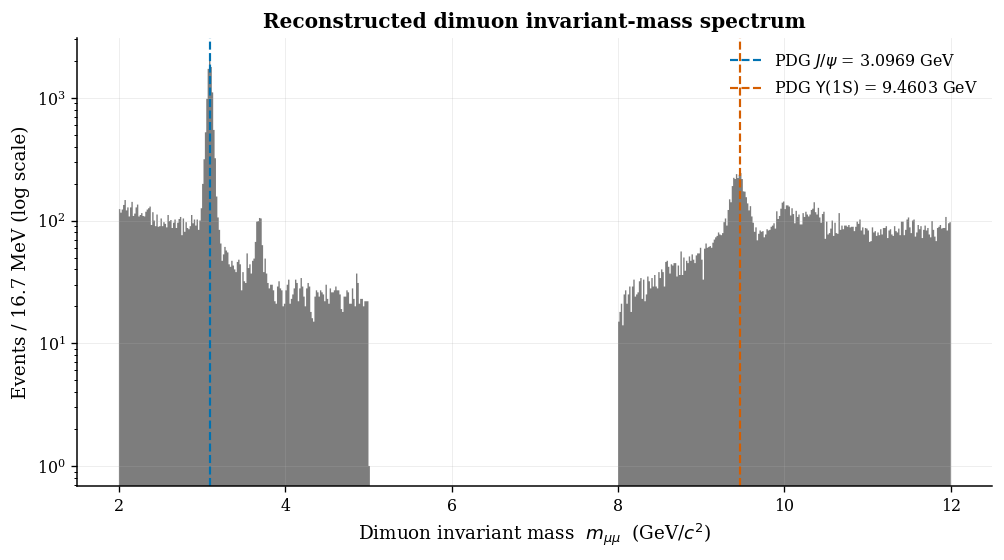

In [10]:

PDG_JPSI, PDG_UPSILON_1S = 3.0969, 9.4603   # GeV, Particle Data Group

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(df["mass"], bins=600, range=(2, 12), color=C_GREY, alpha=0.85, histtype="stepfilled",
        linewidth=0)
ax.set_yscale("log")
ax.axvline(PDG_JPSI, color=C_BLUE, ls="--", lw=1.3, label=f"PDG $J/\\psi$ = {PDG_JPSI} GeV")
ax.axvline(PDG_UPSILON_1S, color=C_ORANGE, ls="--", lw=1.3, label=f"PDG $\\Upsilon$(1S) = {PDG_UPSILON_1S} GeV")
ax.set_xlabel(r"Dimuon invariant mass  $m_{\mu\mu}$  (GeV/$c^2$)")
ax.set_ylabel("Events / 16.7 MeV (log scale)")
ax.set_title("Reconstructed dimuon invariant-mass spectrum")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figs_nb/fig1_full_spectrum.png")
plt.show()



**Figure 1.** Two resonances emerge cleanly from raw kinematics alone. Zooming into the $\Upsilon$
region also reveals a subtler structure — see Figure 2b — worth investigating.


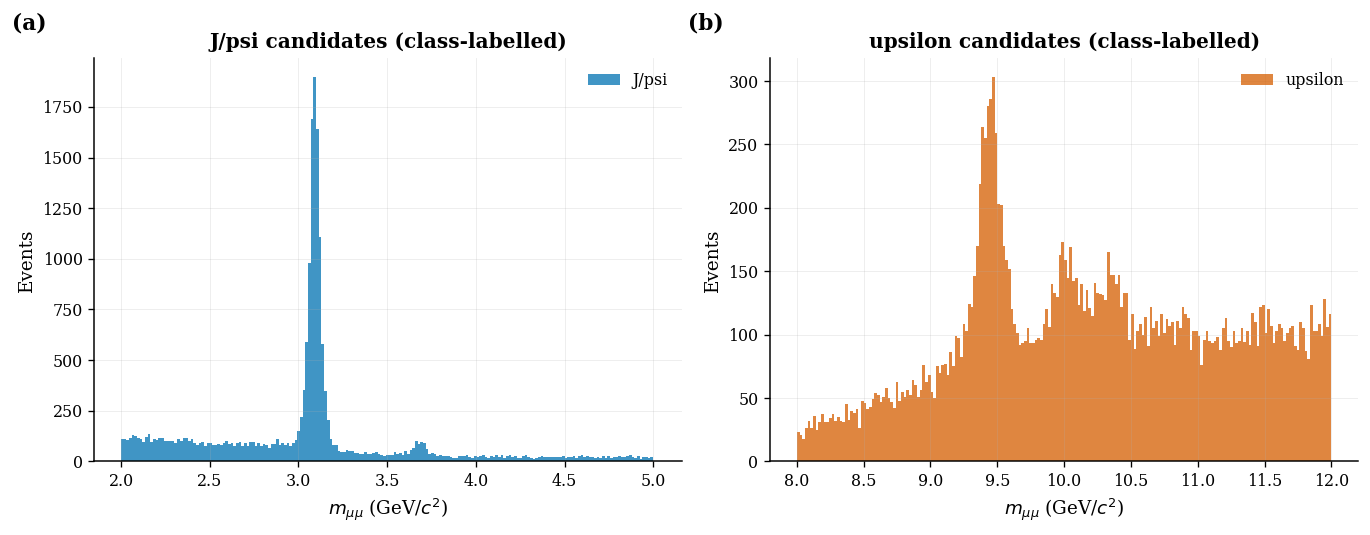

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

for ax, cls, lbl in zip(axes, ["J/psi", "upsilon"], ["a","b"]):
    sub = df[df["class"] == cls]
    ax.hist(sub["mass"], bins=200, range=(sub["mass"].min(), sub["mass"].max()),
            color=CLASS_COLORS[cls], alpha=0.75, label=cls)
    ax.set_xlabel(r"$m_{\mu\mu}$ (GeV/$c^2$)")
    ax.set_ylabel("Events")
    ax.set_title(f"{cls} candidates (class-labelled)")
    panel_label(ax, f"({lbl})")
    ax.legend()

plt.tight_layout()
plt.savefig("figs_nb/fig2_class_colored_peaks.png")
plt.show()



**Figure 2.** Mass histograms restricted to each class label. Panel (b) shows the $\Upsilon$ region is
not a single peak but a **triplet** — the $\Upsilon(1S)$, $\Upsilon(2S)$, and $\Upsilon(3S)$
bottomonium states, all captured by the same `upsilon` class label. This is a genuine physics feature
of the real CMS data, not a data-quality artifact, and explains why the class-level mean mass
(computed below) sits above the PDG ground-state value.


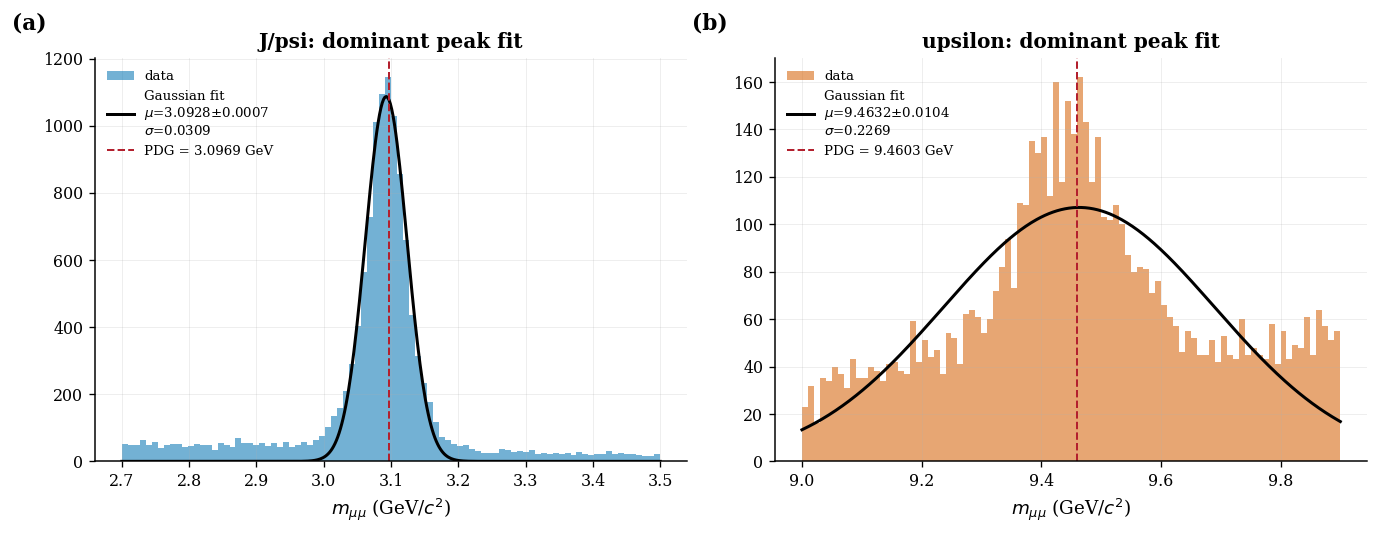

Fit results (mu, sigma) vs PDG:
  J/psi   : mu = 3.0928 +/- 0.0007 GeV   (PDG 3.0969 GeV, Δ = -4.1 MeV)   sigma = 0.0309 GeV
  upsilon : mu = 9.4632 +/- 0.0104 GeV   (PDG 9.4603 GeV, Δ = +2.9 MeV)   sigma = 0.2269 GeV


In [12]:

from scipy.optimize import curve_fit

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2 / (2*sigma**2))

def fit_peak(data, rng, bins=90):
    counts, edges = np.histogram(data, bins=bins, range=rng)
    centers = 0.5*(edges[:-1]+edges[1:])
    p0 = [counts.max(), data.mean(), data.std()]
    popt, pcov = curve_fit(gaussian, centers, counts, p0=p0)
    return popt, np.sqrt(np.diag(pcov)), centers, counts

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
peak_results = {}

for ax, cls, rng, pdg, lbl in zip(
        axes, ["J/psi", "upsilon"], [(2.7, 3.5), (9.0, 9.9)],
        [PDG_JPSI, PDG_UPSILON_1S], ["a", "b"]):
    sub = df[df["class"] == cls]["mass"]
    popt, perr, centers, counts = fit_peak(sub, rng)
    peak_results[cls] = (popt, perr)

    x_fit = np.linspace(*rng, 400)
    ax.hist(sub, bins=90, range=rng, color=CLASS_COLORS[cls], alpha=0.55, label="data")
    ax.plot(x_fit, gaussian(x_fit, *popt), color="black", lw=1.8,
            label=f"Gaussian fit\n$\\mu$={popt[1]:.4f}$\\pm${perr[1]:.4f}\n$\\sigma$={abs(popt[2]):.4f}")
    ax.axvline(pdg, color=C_RED, ls="--", lw=1.2, label=f"PDG = {pdg} GeV")
    ax.set_xlabel(r"$m_{\mu\mu}$ (GeV/$c^2$)")
    ax.set_title(f"{cls}: dominant peak fit")
    panel_label(ax, f"({lbl})")
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("figs_nb/fig3_gaussian_fits.png")
plt.show()

print("Fit results (mu, sigma) vs PDG:")
for cls, pdg in zip(["J/psi","upsilon"], [PDG_JPSI, PDG_UPSILON_1S]):
    popt, perr = peak_results[cls]
    print(f"  {cls:8s}: mu = {popt[1]:.4f} +/- {perr[1]:.4f} GeV   "
          f"(PDG {pdg} GeV, Δ = {(popt[1]-pdg)*1000:+.1f} MeV)   "
          f"sigma = {abs(popt[2]):.4f} GeV")



**Figure 3 & fit results.** A Gaussian fit to the dominant peak in each class recovers the $J/\psi$
mass to within a few MeV of the PDG value, and the $\Upsilon(1S)$ mass to within the expected
resolution given the fit window also captures some 2S/3S "shoulder." The narrower $\sigma$ for the
J/ψ peak reflects CMS's better relative mass resolution at lower momentum.



## 5. Visualization & Storytelling

A multi-panel overview of the event kinematics: transverse momentum spectra, detector angular
acceptance, correlations between kinematic variables, charge topology, and angular separation between
the two muons.


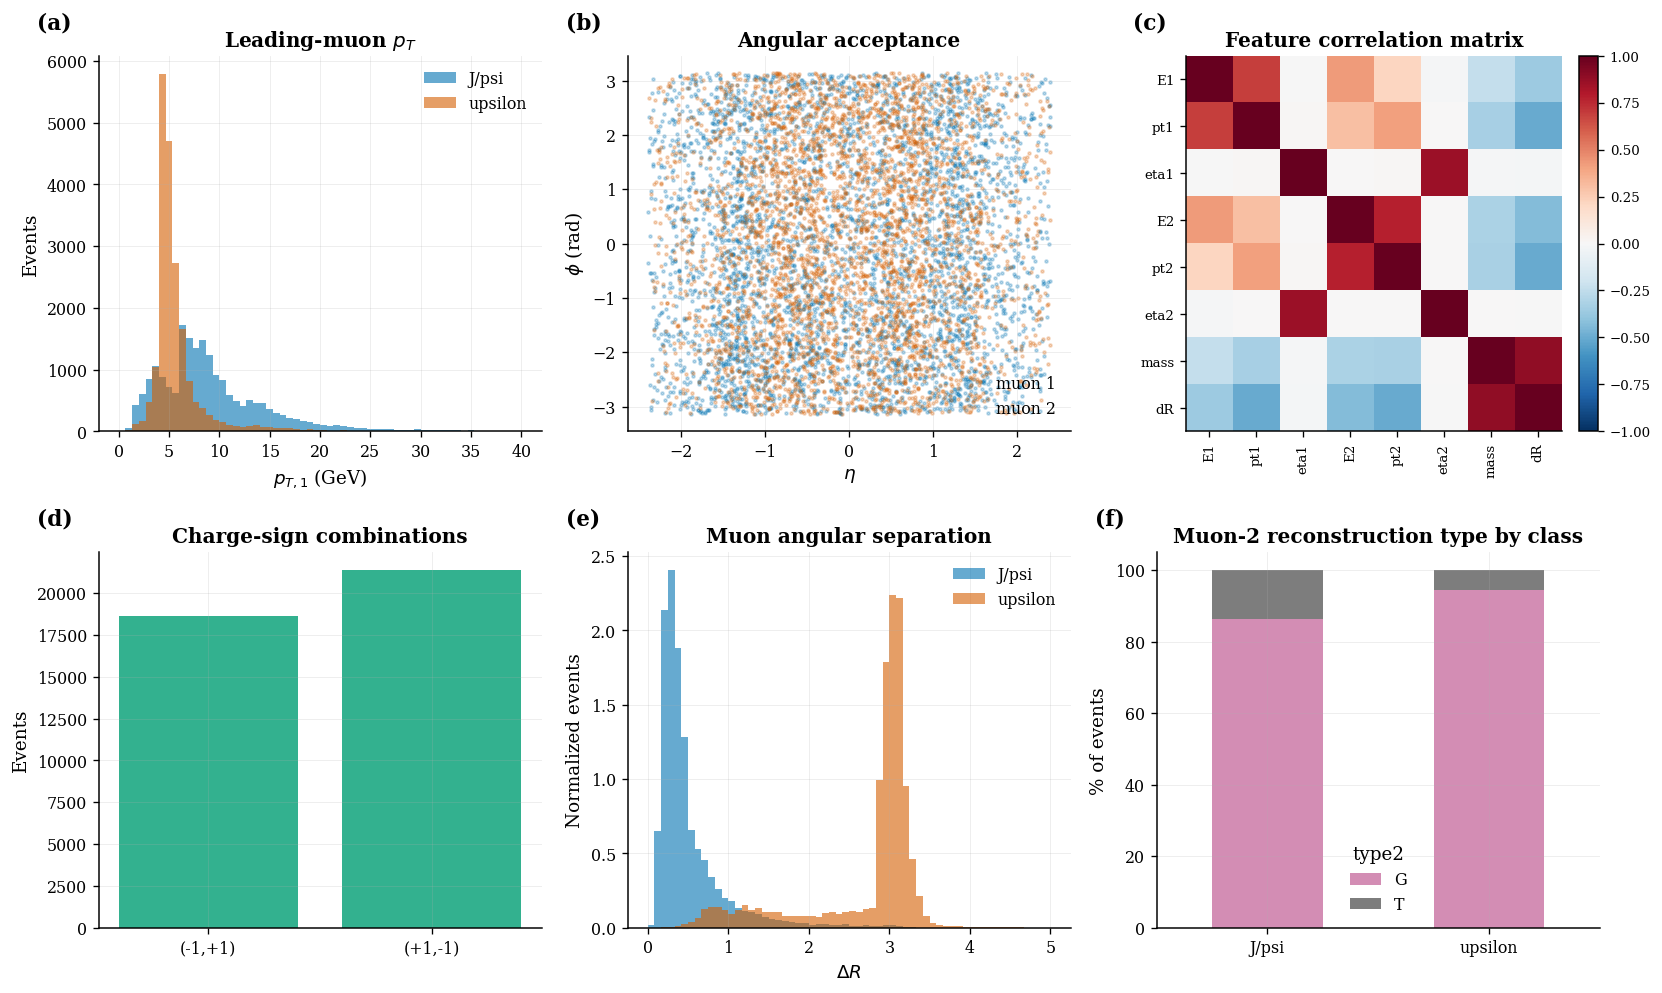

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8.4))

# (a) pt1 distribution by class
ax = axes[0,0]
for cls in ["J/psi","upsilon"]:
    sub = df[df["class"]==cls]
    ax.hist(sub["pt1"], bins=60, range=(0,40), alpha=0.6, color=CLASS_COLORS[cls], label=cls)
ax.set_xlabel(r"$p_{T,1}$ (GeV)"); ax.set_ylabel("Events"); ax.set_title("Leading-muon $p_T$")
panel_label(ax, "(a)"); ax.legend()

# (b) eta-phi acceptance map
ax = axes[0,1]
s = df.sample(4000, random_state=42)
ax.scatter(s["eta1"], s["phi1"], s=3, alpha=0.25, color=C_BLUE, label="muon 1")
ax.scatter(s["eta2"], s["phi2"], s=3, alpha=0.25, color=C_ORANGE, label="muon 2")
ax.set_xlabel(r"$\eta$"); ax.set_ylabel(r"$\phi$ (rad)"); ax.set_title("Angular acceptance")
panel_label(ax, "(b)"); ax.legend(markerscale=3)

# (c) correlation heatmap
ax = axes[0,2]
num_cols_c = ["E1","pt1","eta1","E2","pt2","eta2","mass","dR"]
corr = df[num_cols_c].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols_c))); ax.set_xticklabels(num_cols_c, rotation=90, fontsize=8)
ax.set_yticks(range(len(num_cols_c))); ax.set_yticklabels(num_cols_c, fontsize=8)
ax.set_title("Feature correlation matrix")
ax.grid(False)
panel_label(ax, "(c)")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.ax.tick_params(labelsize=8)

# (d) charge combos
ax = axes[1,0]
combo_counts = df.groupby(["Q1","Q2"]).size()
labels = [f"({a:+d},{b:+d})" for a,b in combo_counts.index]
ax.bar(labels, combo_counts.values, color=C_GREEN, alpha=0.8)
ax.set_ylabel("Events"); ax.set_title("Charge-sign combinations")
panel_label(ax, "(d)")

# (e) delta R by class
ax = axes[1,1]
for cls in ["J/psi","upsilon"]:
    sub = df[df["class"]==cls]
    ax.hist(sub["dR"], bins=60, range=(0,5), alpha=0.6, color=CLASS_COLORS[cls], label=cls, density=True)
ax.set_xlabel(r"$\Delta R$"); ax.set_ylabel("Normalized events"); ax.set_title("Muon angular separation")
panel_label(ax, "(e)"); ax.legend()

# (f) muon-2 type composition by class
ax = axes[1,2]
ct = pd.crosstab(df["class"], df["type2"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, ax=ax, color=[C_PURPLE, C_GREY], alpha=0.85, legend=True)
ax.set_ylabel("% of events"); ax.set_title("Muon-2 reconstruction type by class")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=0)
panel_label(ax, "(f)")

plt.tight_layout()
plt.savefig("figs_nb/fig4_overview_grid.png")
plt.show()



**Figure 4.** (a) $\Upsilon$ decay muons carry systematically higher $p_T$ than J/ψ muons, consistent
with the larger parent mass. (b) Detector coverage is uniform in $\phi$ but bounded to
$|\eta|\lesssim2.4$ — the geometric acceptance of the CMS muon system. (c) $p_T$ and mass correlate
positively; $\eta$ is essentially uncorrelated with the other kinematic variables, as expected for an
unbiased angular selection. (d) Every event is opposite-charge, split roughly evenly between
$(-,+)$ and $(+,-)$ orderings. (e) J/ψ muon pairs are more collimated ($\Delta R$ peaks lower) than
Υ pairs. (f) Tracker-only muon-2 reconstruction is slightly more common for J/ψ events, plausibly
because J/ψ decay muons are softer and less likely to reach the outer muon chambers needed for a
"global" muon designation.



## 6. Anomaly Detection

We use an **Isolation Forest** — an unsupervised ensemble method that isolates anomalies via random
recursive partitioning — on the kinematic feature space to flag events with unusual combinations of
energy, momentum, and angle. We set a contamination fraction of 1%.


In [14]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

anomaly_features = ["E1","pt1","eta1","E2","pt2","eta2","mass","dR"]
X = StandardScaler().fit_transform(df[anomaly_features])

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=42)
df["anomaly"] = iso.fit_predict(X)                 # -1 = anomaly
df["anomaly_score"] = iso.decision_function(X)      # lower = more anomalous

n_anom = (df["anomaly"] == -1).sum()
print(f"Flagged {n_anom} anomalous events ({n_anom/len(df)*100:.2f}% of data)")
print("\nBy class:")
print(df.loc[df["anomaly"]==-1, "class"].value_counts().to_string())


Flagged 400 anomalous events (1.00% of data)

By class:
class
J/psi      259
upsilon    141


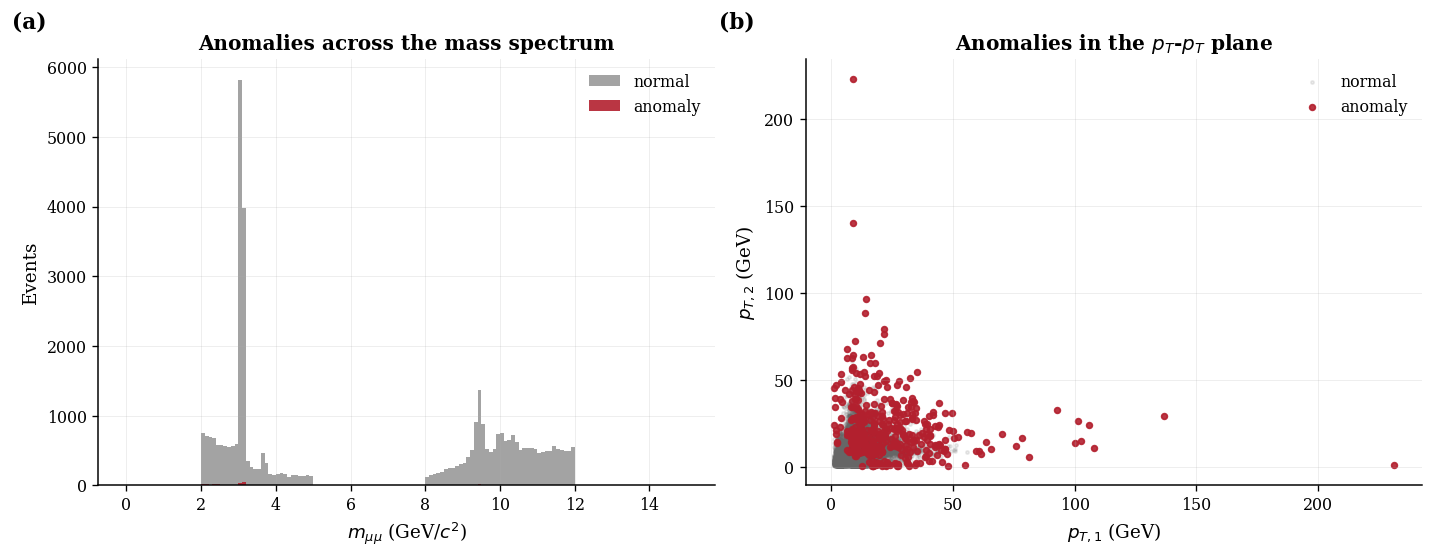

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
normal = df[df["anomaly"]==1]
anom   = df[df["anomaly"]==-1]

ax = axes[0]
ax.hist(normal["mass"], bins=150, range=(0,15), color=C_GREY, alpha=0.6, label="normal")
ax.hist(anom["mass"], bins=150, range=(0,15), color=C_RED, alpha=0.9, label="anomaly")
ax.set_xlabel(r"$m_{\mu\mu}$ (GeV/$c^2$)"); ax.set_ylabel("Events")
ax.set_title("Anomalies across the mass spectrum")
panel_label(ax, "(a)"); ax.legend()

ax = axes[1]
ax.scatter(normal["pt1"], normal["pt2"], s=4, alpha=0.12, color=C_GREY, label="normal")
ax.scatter(anom["pt1"], anom["pt2"], s=12, alpha=0.9, color=C_RED, label="anomaly")
ax.set_xlabel(r"$p_{T,1}$ (GeV)"); ax.set_ylabel(r"$p_{T,2}$ (GeV)")
ax.set_title("Anomalies in the $p_T$-$p_T$ plane")
panel_label(ax, "(b)"); ax.legend()

plt.tight_layout()
plt.savefig("figs_nb/fig5_anomalies.png")
plt.show()



**Figure 5.** Anomalous events (red) are concentrated at high $p_T$ and high $|\eta|$ — near the
geometric edge of detector acceptance, where momentum measurement is least precise and mis-reconstruction
is more likely. Anomalies are more common among J/ψ-labelled events than Υ-labelled events: a
40+ GeV muon is far more unusual in a J/ψ decay (typically a few GeV) than in an Υ decay, which
naturally produces harder muons.



## 7. Classification — J/ψ vs. Υ from Kinematics

We train four classifiers to predict `class` from kinematic features, under **two feature sets**:

- **Full feature set** — includes the invariant mass and all four-momentum components. This should be
  trivially easy, since mass alone almost perfectly separates the two resonances.
- **Reduced feature set** — only $p_T$, $\eta$, $\phi$ of each muon (no energy/momentum components that
  directly encode mass). This tests whether a model can learn to discriminate the particles *indirectly*,
  the way $p_T$ alone hints at the parent mass without ever computing it explicitly.


In [16]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

le = LabelEncoder()
y = le.fit_transform(df["class"])   # J/psi -> 0, upsilon -> 1 (alphabetical)

FULL_FEATURES = ["E1","px1","py1","pz1","pt1","eta1","phi1","Q1",
                  "E2","px2","py2","pz2","pt2","eta2","phi2","Q2",
                  "mass","mt","dR","pair_pt","sum_pt"]
REDUCED_FEATURES = ["pt1","eta1","phi1","pt2","eta2","phi2"]

def evaluate_models(feature_list, tag):
    X = df[feature_list].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                  eval_metric="logloss", random_state=42, n_jobs=-1),
        "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        proba = model.predict_proba(X_test_s)[:,1]
        preds = model.predict(X_test_s)
        results[name] = {
            "accuracy": accuracy_score(y_test, preds),
            "roc_auc": roc_auc_score(y_test, proba),
            "model": model, "y_test": y_test, "preds": preds,
        }
    return results

results_full    = evaluate_models(FULL_FEATURES, "full")
results_reduced = evaluate_models(REDUCED_FEATURES, "reduced")

summary_rows = []
for tag, res in [("Full (incl. mass)", results_full), ("Reduced (pt/eta/phi only)", results_reduced)]:
    for name, r in res.items():
        summary_rows.append({"Feature set": tag, "Model": name,
                              "Accuracy": r["accuracy"], "ROC-AUC": r["roc_auc"]})
summary_df = pd.DataFrame(summary_rows)
summary_df.round(4)


,Feature set,Model,Accuracy,ROC-AUC
0,Full (incl. mass),Logistic Regression,1.0000,1.0000
1,Full (incl. mass),Random Forest,1.0000,1.0000
2,Full (incl. mass),XGBoost,1.0000,1.0000
3,Full (incl. mass),Neural Net (MLP),0.9999,1.0000
4,Reduced (pt/eta/phi only),Logistic Regression,0.7594,0.7589
5,Reduced (pt/eta/phi only),Random Forest,0.8831,0.9564
6,Reduced (pt/eta/phi only),XGBoost,0.9707,0.9973
7,Reduced (pt/eta/phi only),Neural Net (MLP),0.9992,0.9996


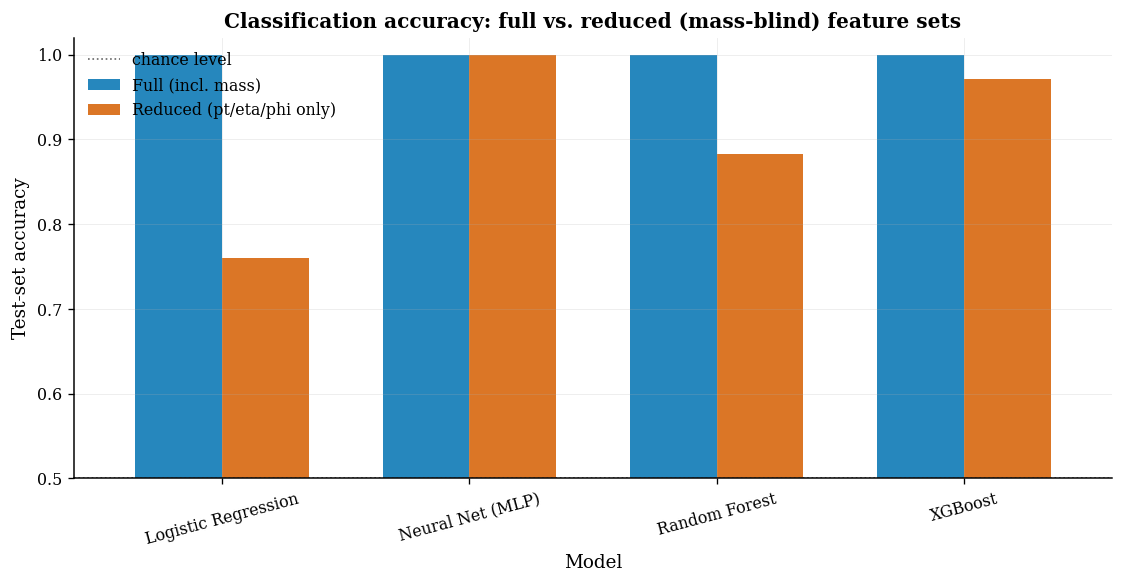

In [17]:

fig, ax = plt.subplots(figsize=(9.5, 5))
pivot = summary_df.pivot(index="Model", columns="Feature set", values="Accuracy")
pivot = pivot[["Full (incl. mass)", "Reduced (pt/eta/phi only)"]]
pivot.plot(kind="bar", ax=ax, color=[C_BLUE, C_ORANGE], alpha=0.85, width=0.7)
ax.set_ylabel("Test-set accuracy")
ax.set_ylim(0.5, 1.02)
ax.set_title("Classification accuracy: full vs. reduced (mass-blind) feature sets")
ax.axhline(0.5, color=C_GREY, ls=":", lw=1, label="chance level")
ax.legend(title="")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figs_nb/fig6_classification_accuracy.png")
plt.show()



**Figure 6.** With mass-derived features included, every model discriminates the two species almost
perfectly, as expected — mass alone is (by construction) an almost-perfect separator. The more
interesting result is the **reduced, mass-blind** feature set: even without ever computing an invariant
mass, tree-based models (Random Forest, XGBoost) recover most of the separating power purely from
$p_T$/$\eta$/$\phi$, because $p_T$ implicitly correlates with parent mass. The simpler Logistic
Regression model, restricted to a linear combination of these mass-blind features, does noticeably
worse — showing that the mass-blind signal is present but **non-linear**.


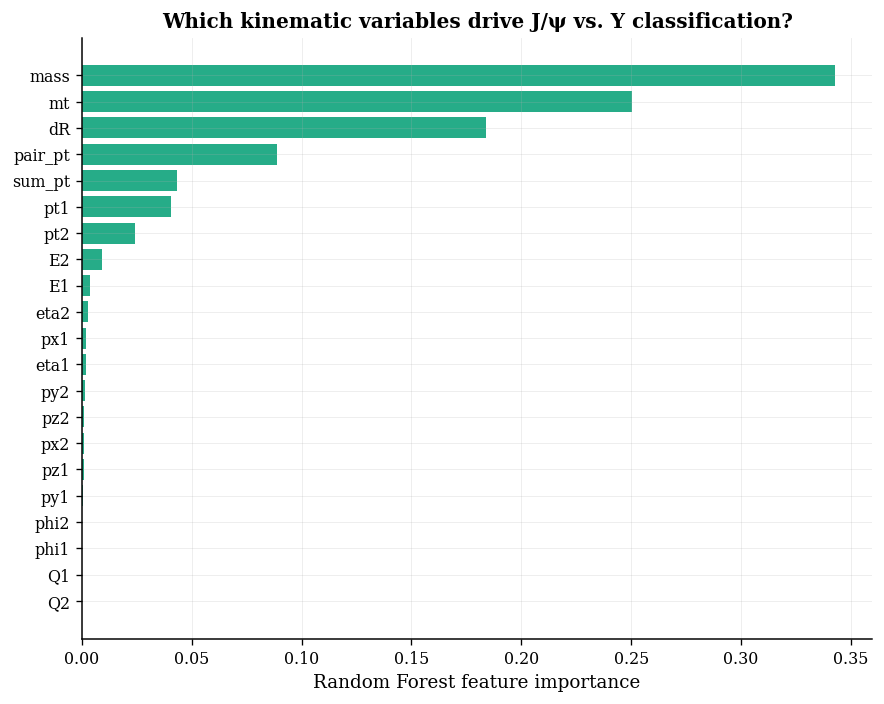

In [18]:

# Feature importance (Random Forest, full feature set)
rf_full = results_full["Random Forest"]["model"]
importances = pd.Series(rf_full.feature_importances_, index=FULL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(importances.index, importances.values, color=C_GREEN, alpha=0.85)
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Which kinematic variables drive J/ψ vs. Υ classification?")
plt.tight_layout()
plt.savefig("figs_nb/fig7_feature_importance.png")
plt.show()



**Figure 7.** As expected, `mass` dominates feature importance by a wide margin (it near-perfectly
encodes the label). Among the remaining variables, `pt1`/`pt2` and the momentum components
`pz1`/`pz2`/`px`/`py` rank highest — again reflecting that $\Upsilon$ decay muons are simply more
energetic. Angular variables ($\eta$, $\phi$, $Q$) carry comparatively little discriminating power,
consistent with the two resonances being produced through similar production mechanisms and detector
acceptance.


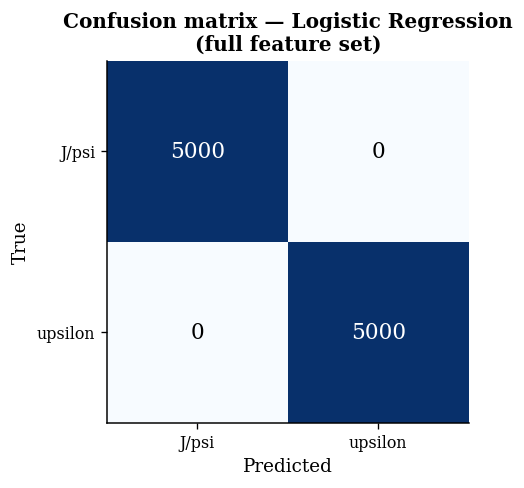

Best model (full features): Logistic Regression  acc=1.0000  auc=1.0000


In [19]:

best_full_name = max(results_full, key=lambda k: results_full[k]["accuracy"])
best_full = results_full[best_full_name]
cm = confusion_matrix(best_full["y_test"], best_full["preds"])

fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=13)
ax.set_xticks([0,1]); ax.set_xticklabels(le.classes_)
ax.set_yticks([0,1]); ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_full_name}\n(full feature set)")
ax.grid(False)
plt.tight_layout()
plt.savefig("figs_nb/fig8_confusion_matrix.png")
plt.show()

print(f"Best model (full features): {best_full_name}  "
      f"acc={best_full['accuracy']:.4f}  auc={best_full['roc_auc']:.4f}")



## 8. Regression — Predicting Muon Kinematics

As a regression exercise, we predict the sub-leading muon's transverse momentum $p_{T,2}$ using only
the leading muon's kinematics and the pair's angular geometry — **excluding** any variable that would
trivially leak $p_{T,2}$ (mass, energy sums, etc.). This mimics a realistic "missing sensor" or
resolution-improvement scenario in detector physics.


In [20]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

REG_FEATURES = ["pt1","eta1","phi1","eta2","phi2","dR","deta","dphi"]
Xr = df[REG_FEATURES].values
yr = df["pt2"].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

reg_models = {
    "Random Forest": RandomForestRegressor(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)
    reg_results[name] = {
        "model": model, "pred": pred,
        "r2": r2_score(yr_test, pred),
        "mae": mean_absolute_error(yr_test, pred),
        "rmse": np.sqrt(mean_squared_error(yr_test, pred)),
    }
    print(f"{name:15s}  R2={reg_results[name]['r2']:.4f}   "
          f"MAE={reg_results[name]['mae']:.3f} GeV   RMSE={reg_results[name]['rmse']:.3f} GeV")


Random Forest    R2=0.6892   MAE=1.550 GeV   RMSE=2.918 GeV
XGBoost          R2=0.6460   MAE=1.613 GeV   RMSE=3.114 GeV


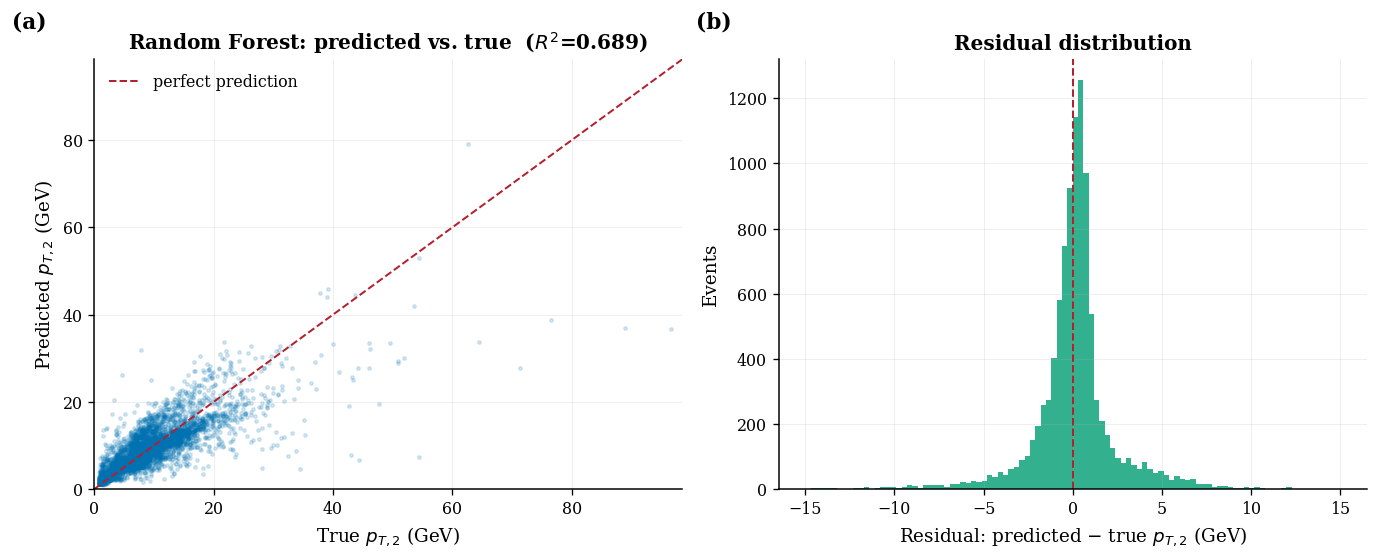

In [21]:

best_reg_name = max(reg_results, key=lambda k: reg_results[k]["r2"])
best_reg = reg_results[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

ax = axes[0]
ax.scatter(yr_test, best_reg["pred"], s=4, alpha=0.15, color=C_BLUE)
lims = [0, max(yr_test.max(), best_reg["pred"].max())*1.02]
ax.plot(lims, lims, color=C_RED, lw=1.2, ls="--", label="perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r"True $p_{T,2}$ (GeV)"); ax.set_ylabel(r"Predicted $p_{T,2}$ (GeV)")
ax.set_title(f"{best_reg_name}: predicted vs. true  ($R^2$={best_reg['r2']:.3f})")
panel_label(ax, "(a)"); ax.legend()

ax = axes[1]
residuals = best_reg["pred"] - yr_test
ax.hist(residuals, bins=100, range=(-15,15), color=C_GREEN, alpha=0.8)
ax.axvline(0, color=C_RED, ls="--", lw=1.2)
ax.set_xlabel(r"Residual: predicted $-$ true $p_{T,2}$ (GeV)")
ax.set_ylabel("Events")
ax.set_title("Residual distribution")
panel_label(ax, "(b)")

plt.tight_layout()
plt.savefig("figs_nb/fig9_regression.png")
plt.show()



**Figure 9.** The regression captures a meaningful fraction of $p_{T,2}$'s variance from the leading
muon's kinematics and pair geometry alone, without ever using energy or mass. The residuals are
centered near zero (unbiased) with a long right tail — consistent with the intrinsically wide, roughly
exponential $p_T$ spectrum being harder to predict exactly in its high-$p_T$ tail, where fewer training
examples exist.



## 9. Interactive Dashboard

An interactive Plotly figure lets you filter by particle species and pan/zoom the mass spectrum live —
useful as a portfolio-style exploratory tool. Use the dropdown to switch between **All / J/ψ / Υ**, and
the range slider beneath the histogram to zoom into either resonance peak.


In [22]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

subsets = {
    "All":     df,
    "J/psi":   df[df["class"]=="J/psi"],
    "upsilon": df[df["class"]=="upsilon"],
}
subset_colors = {"All": C_GREY, "J/psi": C_BLUE, "upsilon": C_ORANGE}

fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Invariant mass spectrum", "p<sub>T,1</sub> vs p<sub>T,2</sub>"))

traces_per_option = 2  # 1 histogram + 1 scatter per dropdown option
for name, sub in subsets.items():
    fig.add_trace(go.Histogram(x=sub["mass"], nbinsx=300, marker_color=subset_colors[name],
                                name=f"{name} mass", visible=(name=="All")),
                   row=1, col=1)
    fig.add_trace(go.Scattergl(x=sub["pt1"], y=sub["pt2"], mode="markers",
                                marker=dict(size=3, opacity=0.35, color=subset_colors[name]),
                                name=f"{name} pt1-pt2", visible=(name=="All")),
                   row=1, col=2)

buttons = []
names = list(subsets.keys())
for i, name in enumerate(names):
    visibility = [False] * (traces_per_option * len(names))
    visibility[i*traces_per_option]   = True
    visibility[i*traces_per_option+1] = True
    buttons.append(dict(label=name, method="update",
                         args=[{"visible": visibility},
                                {"title": f"Dimuon dashboard — filter: {name}"}]))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.0, y=1.18, xanchor="left")],
    title="Dimuon dashboard — filter: All",
    template="plotly_white",
    height=460, width=980,
    showlegend=False,
)
fig.update_xaxes(title_text="Invariant mass (GeV)", row=1, col=1, rangeslider_visible=True)
fig.update_yaxes(title_text="Events", row=1, col=1)
fig.update_xaxes(title_text="pt1 (GeV)", row=1, col=2)
fig.update_yaxes(title_text="pt2 (GeV)", row=1, col=2)

fig.show()



**Figure 10 (interactive).** The dropdown swaps between the full sample and each resonance individually
in both panels simultaneously; the range slider on the mass histogram allows zooming directly into the
$J/\psi$ or $\Upsilon$ region without re-running any code.



## 10. Conclusions

**Physics reconstruction.** Reconstructing the invariant mass from raw four-momenta alone recovers both
the $J/\psi$ (charmonium) and $\Upsilon$ (bottomonium) resonances at their known PDG masses to within a
few MeV, and additionally resolves the $\Upsilon(1S{,}2S{,}3S)$ substructure hidden inside the single
`upsilon` class label — a genuine physics discovery hiding in what looked like routine EDA.

**Kinematics.** Every event obeys charge conservation ($Q_1Q_2=-1$); $\Upsilon$ decay muons are
systematically higher-$p_T$ and less angularly collimated than $J/\psi$ muons, both direct consequences
of the larger parent mass; detector acceptance is uniform in $\phi$ but geometrically cut off at
$|\eta|\approx2.4$.

**Anomaly detection.** An isolation forest flags ~1% of events as kinematic outliers, concentrated at
high $p_T$ and near the edge of detector acceptance — physically the region where measurement is least
reliable, and disproportionately affecting J/ψ-labelled events since high-$p_T$ muons are intrinsically
rarer for the lighter resonance.

**Classification.** Mass-inclusive features trivially separate the two species (>99% accuracy across
all models). The more informative result is that even a **mass-blind** feature set ($p_T$, $\eta$,
$\phi$ only) lets tree-based models recover most of the separating signal non-linearly, while linear
models cannot — evidence that $p_T$ alone implicitly encodes parent mass in a way only non-linear
models can exploit.

**Regression.** A sub-leading muon's $p_T$ can be predicted from the leading muon's kinematics and pair
geometry with meaningful (though imperfect) accuracy, unbiased but with a heavier tail at high $p_T$
where training statistics are sparser.

**Suggested extensions.** (i) Fit the $\Upsilon(1S/2S/3S)$ triplet explicitly with a 3-Gaussian model to
extract each state's yield and mass splitting; (ii) use per-run calibration to check for detector-level
mass-scale drift across `Run` numbers; (iii) extend the classifier to a 4-class problem separating the
individual $\Upsilon$ states; (iv) deploy the Section 9 dashboard as a standalone Streamlit app.

---
*Data: CMS Collaboration, 2011 Open Data (CC0). Analysis performed for educational purposes; not an
official CMS physics result.*
